# Tabby English — Phase 1 (양방향 대화)

> IDE의 자동완성처럼, 영어로 말하다 막히는 순간 다음 표현을 띄워주는 회화 코칭 에이전트

이 Notebook은 LangGraph 파이프라인을 단계별로 실행하며 학습하기 위한 것입니다.  
AI 대화 상대(카페 직원, 면접관 등)와 영어로 대화하고, 종료 시 학습 피드백을 받습니다.

## 대화 흐름

1. 시나리오 설정 (예: "ordering at a cafe")
2. 사용자 발화 → AI가 시나리오에 맞는 응답 생성 (반복)
3. `"end"` 입력 → 전체 대화 분석 후 피드백


---

## 1. 환경 설정


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT: Path = Path.cwd().resolve()

if not (PROJECT_ROOT / "src").is_dir():
    raise RuntimeError(
        f"프로젝트 루트를 찾을 수 없습니다.\n"
        f"현재 위치: {PROJECT_ROOT}\n"
        f"main.ipynb를 프로젝트 루트(tabby-english/)에 두고 실행해주세요."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("프로젝트 루트:", PROJECT_ROOT)

프로젝트 루트: C:\Users\yun\Documents\code\tabby-english


In [2]:
import json
from typing import cast

from dotenv import load_dotenv
from langgraph.graph.state import CompiledStateGraph

from src.graph import build_graph
from src.state import ConversationState, Feedback

load_dotenv()
print("라이브러리 import 완료")

라이브러리 import 완료


---

## 2. 그래프 빌드 + 구조 확인

이번에는 `generate_ai_response` 노드가 추가되어, `analyze_utterance`에서 두 갈래로 분기합니다:

- `session_ended=False` → `generate_ai_response` (AI가 대답)
- `session_ended=True` → `generate_feedback` (피드백 생성)


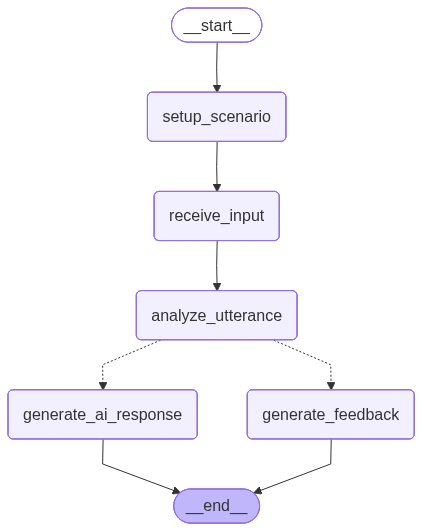

In [3]:
app: CompiledStateGraph = build_graph()

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

---

## 3. 세션 초기화

시나리오를 정하고 초기 State를 만듭니다.


In [4]:
scenario: str = "ordering at a cafe"

state: ConversationState = {
    "scenario": scenario,
    "system_prompt": "",
    "raw_input": "",
    "session_ended": False,
    "conversation_history": [],
    "last_ai_response": "",
    "feedback": {},
}

print(f"시나리오: {scenario}")
print("AI 대화 상대와 대화를 시작할 준비 완료")

시나리오: ordering at a cafe
AI 대화 상대와 대화를 시작할 준비 완료


---

## 4. 대화 (한 셀 = 한 턴, 반복 실행)

아래 셀의 `user_input` 값을 매번 바꿔가며 실행하세요.  
한 번 실행할 때마다:

1. 사용자 발화가 history에 누적됨
2. AI가 시나리오에 맞춰 자연스럽게 응답
3. AI 응답도 history에 누적됨

**팁**: AI는 카페 직원처럼 행동하므로, 직원이 던진 질문에 자연스럽게 응답해보세요.


In [ ]:
# 매 턴 이 부분만 바꿔서 실행
user_input: str = "Hi, I would like to order a coffee"

# 그래프 한 사이클 실행
state["raw_input"] = user_input
state = cast(ConversationState, app.invoke(state))

# 채팅 형태로 출력
print(f"You:     {user_input}")
print(f"Partner: {state['last_ai_response']}")

You:     I already have my seat inside. Thank you.
Partner: You're welcome! Enjoy your coffee. If you need anything else, just let me know!


### 전체 대화 기록 확인

지금까지 누적된 대화를 한눈에 보고 싶을 때 실행.


In [10]:
for entry in state["conversation_history"]:
    speaker = "You    " if entry["role"] == "user" else "Partner"
    print(f"{speaker}: {entry['text']}")

You    : Hi, I would like to order a coffee
Partner: Sure! What kind of coffee would you like?
You    : I want a decaf americano and a cup of cold water please.
Partner: Got it! One decaf Americano and a cup of cold water. Would you like anything to eat with that?
You    : done.
Partner: Great! That'll be $5.50. How would you like to pay?
You    : Cash please. Here it is.
Partner: Thank you! Here’s your change. Your coffee will be ready shortly. Do you want to sit inside or outside?
You    : I already have my seat inside. Thank you.
Partner: You're welcome! Enjoy your coffee. If you need anything else, just let me know!


---

## 5. 세션 종료 + 피드백

`raw_input`에 `"end"`를 넣으면 라우터가 `generate_feedback` 노드로 분기하여  
지금까지의 전체 대화를 분석한 학습 피드백을 반환합니다.


In [11]:
state["raw_input"] = "end"
state = cast(ConversationState, app.invoke(state))

feedback: Feedback = state.get("feedback", {})
print(json.dumps(feedback, ensure_ascii=False, indent=2))

c:\Users\yun\Documents\code\tabby-english\.venv\Lib\site-packages\langgraph\_internal\_runnable.py:400: UserWarning: Parameters {'max_tokens'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  ret = self.func(*args, **kwargs)


{
  "summary": "학습자는 카페에서 커피를 주문하는 상황을 잘 표현했습니다. 전반적으로 대화가 매끄럽고 필요한 정보를 잘 전달했습니다.",
  "improvements": [
    {
      "original": "done.",
      "suggestion": "That's all for now.",
      "reason": "주문을 완료했다는 의미를 더 자연스럽게 전달할 수 있는 표현입니다."
    }
  ],
  "good_points": [
    "주문할 때 필요한 정보를 명확하게 전달했습니다.",
    "결제 방법을 요청할 때 'Cash please.'라고 간단명료하게 표현했습니다."
  ]
}


---

## 부록: State 전체 살펴보기


In [12]:
for key, value in state.items():
    if isinstance(value, (list, dict)) and value:
        print(f"{key}:")
        print(json.dumps(value, ensure_ascii=False, indent=2))
    else:
        print(f"{key}: {value!r}")
    print()

scenario: 'ordering at a cafe'

system_prompt: '당신은 한국인 학습자의 영어 회화 연습을 돕는 대화 상대입니다.\n\n상황: ordering at a cafe\n\n규칙:\n- 위 상황에 맞는 역할(예: 카페 직원, 면접관)을 일관되게 유지하세요.\n- 응답은 짧고 자연스럽게 작성하세요. 보통 1~2문장이면 충분합니다.\n- 일상적인 구어체 영어를 사용하세요. 지나치게 격식적이거나 교과서 같은 표현은 피하세요.\n- 학습자가 작은 문법 실수를 하더라도 대화 도중에 교정하지 마세요. 자연스럽게 응답하기만 하면 됩니다.\n- 적절한 시점에 후속 질문을 던져 대화의 흐름을 이어가도록 도와주세요.\n- 모든 응답은 반드시 영어로 작성하세요.'

raw_input: 'end'

session_ended: True

conversation_history:
[
  {
    "role": "user",
    "text": "Hi, I would like to order a coffee",
    "timestamp": "2026-05-05T22:59:54"
  },
  {
    "role": "assistant",
    "text": "Sure! What kind of coffee would you like?",
    "timestamp": "2026-05-05T22:59:57"
  },
  {
    "role": "user",
    "text": "I want a decaf americano and a cup of cold water please.",
    "timestamp": "2026-05-05T23:00:55"
  },
  {
    "role": "assistant",
    "text": "Got it! One decaf Americano and a cup of cold water. Would you like anything to eat with that?",
    "timestamp": "2026-05-05